# 02 — Standardise Vg Log-Scale Display via Config

> Task 2 from `07_permutations/TODO_next_steps.md`  
> Implements `VG_LOG_SCALE` and `VG_MIN_CLIP` flags centralised in `config.py`.

---

## Motivation

`vg_predicted` spans **multiple orders of magnitude** across genes — from near-zero values
(gene windows that accumulate almost no regulatory variation) to values several orders of
magnitude higher in highly polymorphic regions. On a **linear scale** this dynamic range
causes the bulk of the distribution to collapse near zero, making group differences
between ClinGen HI and background genes invisible.

Using a log scale:
- Spreads the distribution uniformly, revealing shape differences
- Makes medians comparable as ratios (log LFC ≡ log ratio of medians)
- Prevents heavy-tailed outliers from dominating visual comparisons

### Goal of this notebook
1. **Quantify** the dynamic range problem via descriptive statistics (min, max, IQR, skewness)
2. **Demonstrate** the linear-vs-log visual difference for all Vg column types
3. **Validate** that `VG_LOG_SCALE = True` is the correct default by checking normality on log scale
4. **Show** that HI-vs-background group separation is visible on log scale but masked on linear
5. **Document** the zero-value strategy using `VG_MIN_CLIP`

---

## Column reference (AGENTS.md)

| Use case | Real sources | Null sources |
|---|---|---|
| Total Vg | `vg_predicted` | `vg_predicted_perm` |
| Common AF Vg | `vg_common` | `vg_common_perm` |
| Rare AF Vg | `vg_rare` | `vg_rare_perm` |
| Spatial regions | `vg_{window}` | `vg_{window}_perm` |

> `vg_predicted_perm_sanity` is **not** used here — QC use only.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [2]:
from config import (
    GENE_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
    VG_LOG_SCALE,
    VG_MIN_CLIP,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '02_vg_log_scale'

print(f'VG_LOG_SCALE = {VG_LOG_SCALE}  (set in config.py)')
print(f'VG_MIN_CLIP  = {VG_MIN_CLIP}   (floor before log-transform)')
print('\nDatasets:')
for name in ['clingen', 'background', 'clingen_null', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')

VG_LOG_SCALE = True  (set in config.py)
VG_MIN_CLIP  = 1e-12   (floor before log-transform)

Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [3]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [4]:
print('df_real columns:', sorted(df_real.columns))
print('df_synth columns:', sorted(df_synth.columns))

candidate_cols = [
    c for c in df_real.columns
    if any(k in c.lower() for k in ['af', 'vg', 'promoter', 'upstream', 'downstream', 'tss', 'region'])
]
print('\nCandidate columns in df_real:')
for c in sorted(candidate_cols):
    print(' ', c)

for col in ['vg_predicted', 'vg_common', 'vg_rare', 'n_variants_common', 'n_variants_rare']:
    if col in df_real.columns:
        print(f"\n{col} summary:")
        print(
            df_real.select(
                pl.col(col).drop_nans().drop_nulls().alias(col)
            ).to_pandas()[col].describe(percentiles=[0.25, 0.5, 0.75])
        )

df_real columns: ['Episcore', 'N85', 'N90', 'RVIS_score', 'af_gradient', 'chrom', 'coding_length', 'cv_effect_N90', 'depletion_common', 'depletion_distal_upstream', 'depletion_down_distal', 'depletion_down_proximal', 'depletion_high_impact', 'depletion_promoter_core', 'depletion_proximal_upstream', 'depletion_rare', 'enrich_vg_distal_upstream', 'enrich_vg_down_distal', 'enrich_vg_down_proximal', 'enrich_vg_promoter_core', 'enrich_vg_proximal_upstream', 'entropy_distal_upstream', 'entropy_down_distal', 'entropy_down_proximal', 'entropy_effect', 'entropy_promoter_core', 'entropy_proximal_upstream', 'exonic_length', 'frac_high_impact_05', 'frac_high_impact_10', 'gene_id', 'gene_symbol', 'gene_type', 'genomic_length', 'intronic_length', 'is_mane', 'loeuf_score', 'mane_transcript_id', 'max_abs_effect', 'max_dist_to_tss', 'max_variant_id', 'max_variant_score', 'mean_abs_distal_upstream', 'mean_abs_down_distal', 'mean_abs_down_proximal', 'mean_abs_effect', 'mean_abs_promoter_core', 'mean_abs_

In [5]:
# -- Load gene-level data (robust concat across real/null schemas) ----------------
SOURCE_ORDER = ['background', 'background_null', 'clingen', 'clingen_null']

# Keep only expected sources and preserve display order
available_sources = [s for s in SOURCE_ORDER if s in GENE_PATHS]
missing_sources = [s for s in SOURCE_ORDER if s not in GENE_PATHS]
if missing_sources:
    print(f'WARNING: missing sources in GENE_PATHS: {missing_sources}')

frames = [
    pl.scan_parquet(GENE_PATHS[src]).with_columns(pl.lit(src).alias('source'))
    for src in available_sources
]

# Real and synthetic files can have non-identical schemas; diagonal_relaxed aligns by column name
df_all = pl.concat(frames, how='diagonal_relaxed').collect()

df_real = df_all.filter(~pl.col('source').str.contains('null'))
df_synth = df_all.filter(pl.col('source').str.contains('null'))

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')

print('Loaded:')
for src in SOURCE_ORDER:
    if src in available_sources:
        n = df_all.filter(pl.col('source') == src).height
        print(f'  {src}: {n} genes')

Loaded:
  background: 349 genes
  background_null: 349 genes
  clingen: 316 genes
  clingen_null: 316 genes


---
## Section 1 — Quantify the dynamic range problem

### Hypothesis
`vg_predicted` is log-normally distributed with a dynamic range spanning ≥4 orders of magnitude.
On a linear scale, the interquartile range collapses into a narrow band near zero, masking
biologically meaningful differences between gene sets.

### Expected direction
- Skewness >> 1 on linear scale, close to 0 on log scale (log-normality)
- IQR/mean ratio >> 1 on linear scale (high relative dispersion)
- Shapiro-Wilk p on log(Vg) should be higher than on raw Vg

### Technical approach
Compute descriptive statistics and normality tests on raw and log-transformed `vg_predicted`
for all four sources.

In [6]:
# ── Descriptive statistics: raw vs log scale ───────────────────────────────────
ALL_VG_COLS = [
    'vg_predicted',
    'vg_common', 'vg_rare',
    'vg_promoter_core',
    'vg_proximal_upstream', 'vg_distal_upstream',
    'vg_down_proximal',     'vg_down_distal',
]

present_cols = [c for c in ALL_VG_COLS if c in df_real.columns]
missing_cols = [c for c in ALL_VG_COLS if c not in df_real.columns]
if missing_cols:
    print(f'WARNING — columns absent from df_real: {missing_cols}')

print(f'Columns available: {present_cols}\n')

rows = []
for src in ['background', 'clingen']:
    sub = df_all.filter(pl.col('source') == src).to_pandas()
    for col in present_cols:
        vals = sub[col].dropna().values
        vals = vals[vals > 0]  # drop exact zeros before log
        if len(vals) < 10:
            continue
        log_vals = np.log10(vals)
        # Shapiro-Wilk on a random subsample (max 5000 to keep test valid)
        sub_idx = np.random.default_rng(42).choice(len(vals), min(len(vals), 5000), replace=False)
        sw_raw_p = stats.shapiro(vals[sub_idx])[1]
        sw_log_p = stats.shapiro(log_vals[sub_idx])[1]
        rows.append({
            'source':     src,
            'column':     col,
            'n':          len(vals),
            'n_zero':     int((sub[col].dropna() == 0).sum()),
            'min':        vals.min(),
            'max':        vals.max(),
            'log10_range': np.log10(vals.max()) - np.log10(vals.min() + VG_MIN_CLIP),
            'median':     np.median(vals),
            'IQR':        np.percentile(vals, 75) - np.percentile(vals, 25),
            'skewness_raw': stats.skew(vals),
            'skewness_log': stats.skew(log_vals),
            'sw_p_raw':   sw_raw_p,
            'sw_p_log':   sw_log_p,
        })

desc_df = pd.DataFrame(rows)

print('Dynamic range summary (log10_range = log10(max/min)):') 
print(desc_df[['source', 'column', 'n', 'n_zero', 'log10_range', 'skewness_raw', 'skewness_log',
               'sw_p_raw', 'sw_p_log']]
      .to_string(index=False, float_format=lambda x: f'{x:.3g}'))
print()
print('Interpretation: skewness_raw >> 0 → heavy right tail on linear scale.')
print('                skewness_log ≈ 0 → log-normal → log scale is appropriate.')
print('                sw_p_log > sw_p_raw → log transformation improves normality.')

Columns available: ['vg_predicted', 'vg_common', 'vg_rare', 'vg_promoter_core', 'vg_proximal_upstream', 'vg_distal_upstream', 'vg_down_proximal', 'vg_down_distal']

Dynamic range summary (log10_range = log10(max/min)):
    source               column   n  n_zero  log10_range  skewness_raw  skewness_log  sw_p_raw  sw_p_log
background         vg_predicted 349       0         5.21          10.1        -0.502  2.98e-34  0.000218
background            vg_common 346       3         8.27          10.9         -1.45  1.31e-34  6.85e-12
background              vg_rare 349       0         4.17          5.73        -0.314  1.61e-31   0.00267
background     vg_promoter_core 333      16         6.33          7.61      -0.00831   1.7e-34    0.0338
background vg_proximal_upstream 333      16         5.57          12.8         0.374  1.89e-36    0.0221
background   vg_distal_upstream 333      16         6.35          6.19       -0.0415  4.24e-32   0.00022
background     vg_down_proximal 333      16   

---
## Section 2 — Linear vs log scale: visual comparison

### Hypothesis
On a linear scale, the `background`/`clingen` Vg distributions visually overlap near zero.
On a log scale, the distributions separate clearly, revealing the depletion of Vg in HI genes.

### Expected direction
- Linear histograms: both distributions compressed near zero, group difference invisible
- Log histograms: approximately bell-shaped, clear left-shift for ClinGen HI

### Technical approach
Side-by-side histogram comparison for `vg_predicted` and the five spatial regions,
controlled by the `VG_LOG_SCALE` flag from `config.py`.

In [7]:
# ── Utility: apply log scale based on config flag ─────────────────────────────

def apply_vg_scale(ax: plt.Axes, axis: str = 'x', log: bool = VG_LOG_SCALE) -> None:
    """
    Apply log or linear scale to the specified axis of ax, according to the
    VG_LOG_SCALE config flag.

    Parameters
    ----------
    ax   : target Axes
    axis : 'x' or 'y'
    log  : override; defaults to config VG_LOG_SCALE
    """
    if log:
        if axis == 'x':
            ax.set_xscale('log')
        else:
            ax.set_yscale('log')


def clip_for_log(vals: np.ndarray, clip: float = VG_MIN_CLIP) -> np.ndarray:
    """Replace values <= 0 with `clip` before log-transform."""
    return np.where(vals <= 0, clip, vals)


print('Utilities ready: apply_vg_scale(), clip_for_log()')
print(f'VG_LOG_SCALE = {VG_LOG_SCALE}  →  log scale is {"ON" if VG_LOG_SCALE else "OFF"}')

Utilities ready: apply_vg_scale(), clip_for_log()
VG_LOG_SCALE = True  →  log scale is ON


/Users/markus/in-silico-vg-analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/markus/in-silico-vg-analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


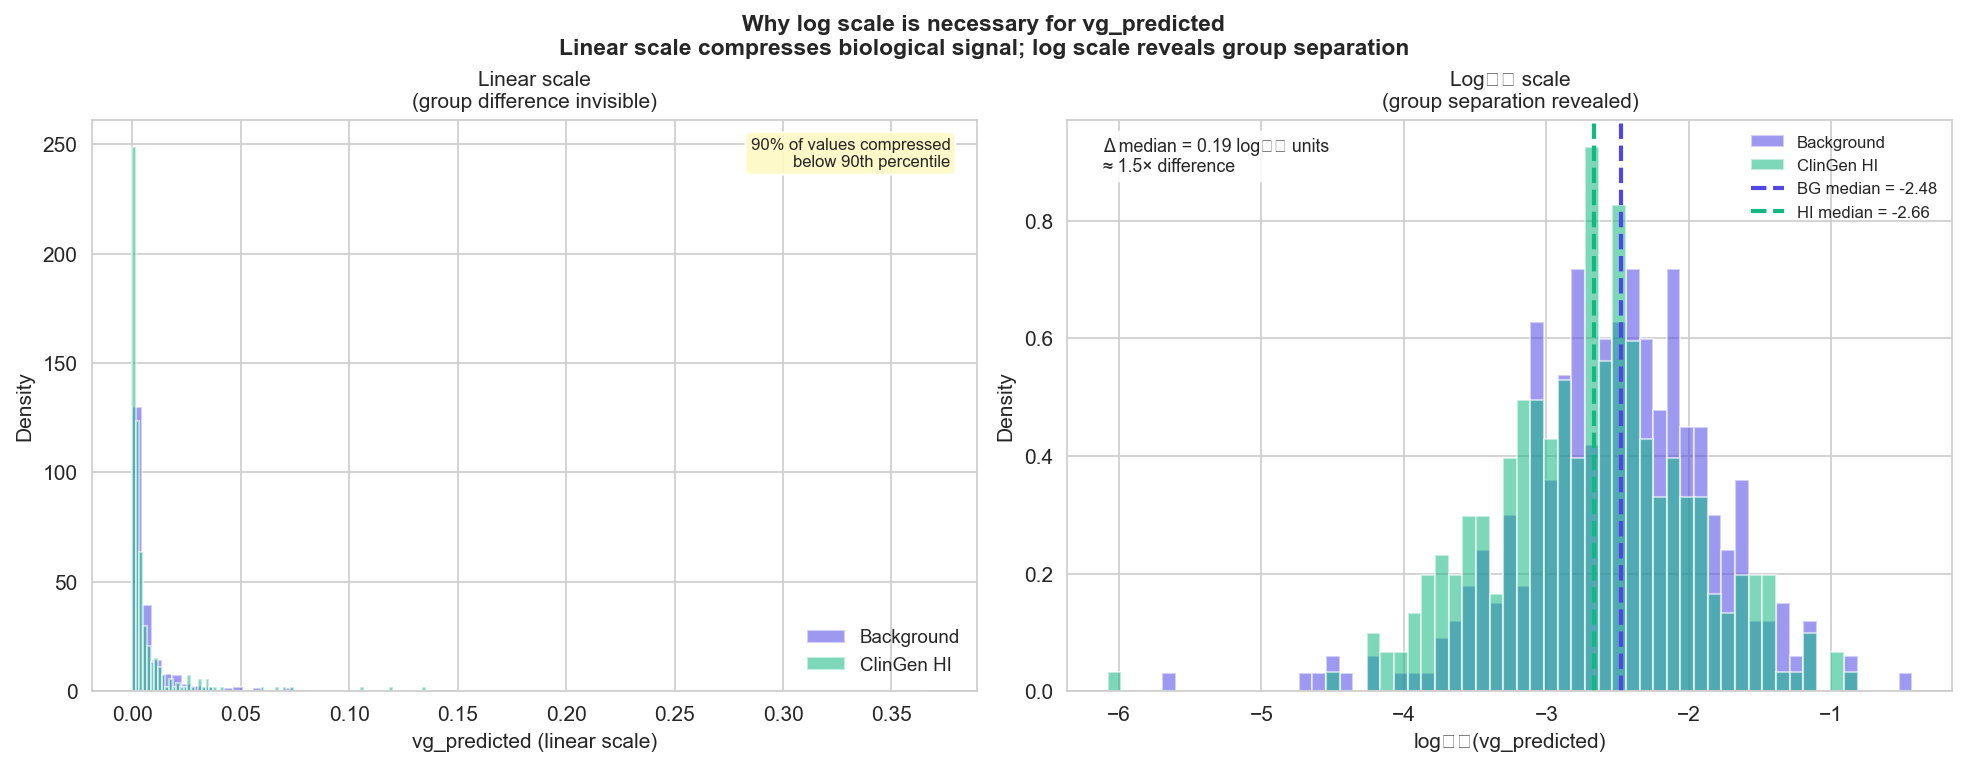

[save_plot] Saved: 02_vg_log_scale_TODO2_LinearVsLog_vg_predicted_14032026_1502.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_LinearVsLog_vg_predicted_14032026_1502.svg


<Figure size 960x720 with 0 Axes>

In [8]:
# ── Linear vs Log: 2-row panel for vg_predicted ───────────────────────────────
# Top row = linear scale, bottom row = log scale

COMPARE_COL  = 'vg_predicted'
hi_vals_raw  = df_hi.select(COMPARE_COL).to_pandas()[COMPARE_COL].dropna().values
bg_vals_raw  = df_bg.select(COMPARE_COL).to_pandas()[COMPARE_COL].dropna().values

hi_vals_log  = np.log10(clip_for_log(hi_vals_raw))
bg_vals_log  = np.log10(clip_for_log(bg_vals_raw))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel A — linear
ax = axes[0]
ax.hist(bg_vals_raw, bins=80, color=SOURCE_PALETTE['background'], alpha=0.55, label='Background', density=True)
ax.hist(hi_vals_raw, bins=80, color=SOURCE_PALETTE['clingen'],    alpha=0.55, label='ClinGen HI', density=True)
ax.set_xlabel('vg_predicted (linear scale)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Linear scale\n(group difference invisible)', fontsize=10)
ax.legend(fontsize=9, frameon=False)

# Annotate compression
pct_below = 100 * (bg_vals_raw < np.percentile(bg_vals_raw, 90)).mean()
ax.text(0.97, 0.97, f'{pct_below:.0f}% of values compressed\nbelow 90th percentile',
        transform=ax.transAxes, fontsize=8, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef9c3', alpha=0.9))

# Panel B — log10
ax = axes[1]
bins_log = np.linspace(hi_vals_log.min(), bg_vals_log.max(), 60)
ax.hist(bg_vals_log, bins=bins_log, color=SOURCE_PALETTE['background'], alpha=0.55, label='Background', density=True)
ax.hist(hi_vals_log, bins=bins_log, color=SOURCE_PALETTE['clingen'],    alpha=0.55, label='ClinGen HI', density=True)

# Median lines
ax.axvline(np.median(bg_vals_log), color=SOURCE_PALETTE['background'], linewidth=2,  linestyle='--', label=f'BG median = {np.median(bg_vals_log):.2f}')
ax.axvline(np.median(hi_vals_log), color=SOURCE_PALETTE['clingen'],    linewidth=2,  linestyle='--', label=f'HI median = {np.median(hi_vals_log):.2f}')
ax.set_xlabel('log₁₀(vg_predicted)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Log₁₀ scale\n(group separation revealed)', fontsize=10)
ax.legend(fontsize=8, frameon=False)

# Annotate delta-median
delta = np.median(bg_vals_log) - np.median(hi_vals_log)
ax.text(0.04, 0.97, f'Δ median = {delta:.2f} log₁₀ units\n≈ {10**delta:.1f}× difference',
        transform=ax.transAxes, fontsize=8.5, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

fig.suptitle(
    'Why log scale is necessary for vg_predicted\n'
    'Linear scale compresses biological signal; log scale reveals group separation',
    fontsize=11, fontweight='bold',
)

with autosave('TODO2_LinearVsLog_vg_predicted', notebook=NOTEBOOK_NAME):
    plt.show()

---
## Section 3 — All Vg columns: log-scale distribution overview

### Hypothesis
Log-normality holds for all Vg column types (total, AF-bin, spatial window), justifying
centralisation of the log-scale flag rather than column-specific overrides.

### Expected direction
All columns are approximately bell-shaped on log₁₀ scale, with consistent HI left-shift
for promoter/downstream regions and a right-shift for upstream regions (from notebook 01).

### Technical approach
Grid of violin plots, one panel per Vg column, with log scale applied via `apply_vg_scale()`.

/Users/markus/in-silico-vg-analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/markus/in-silico-vg-analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


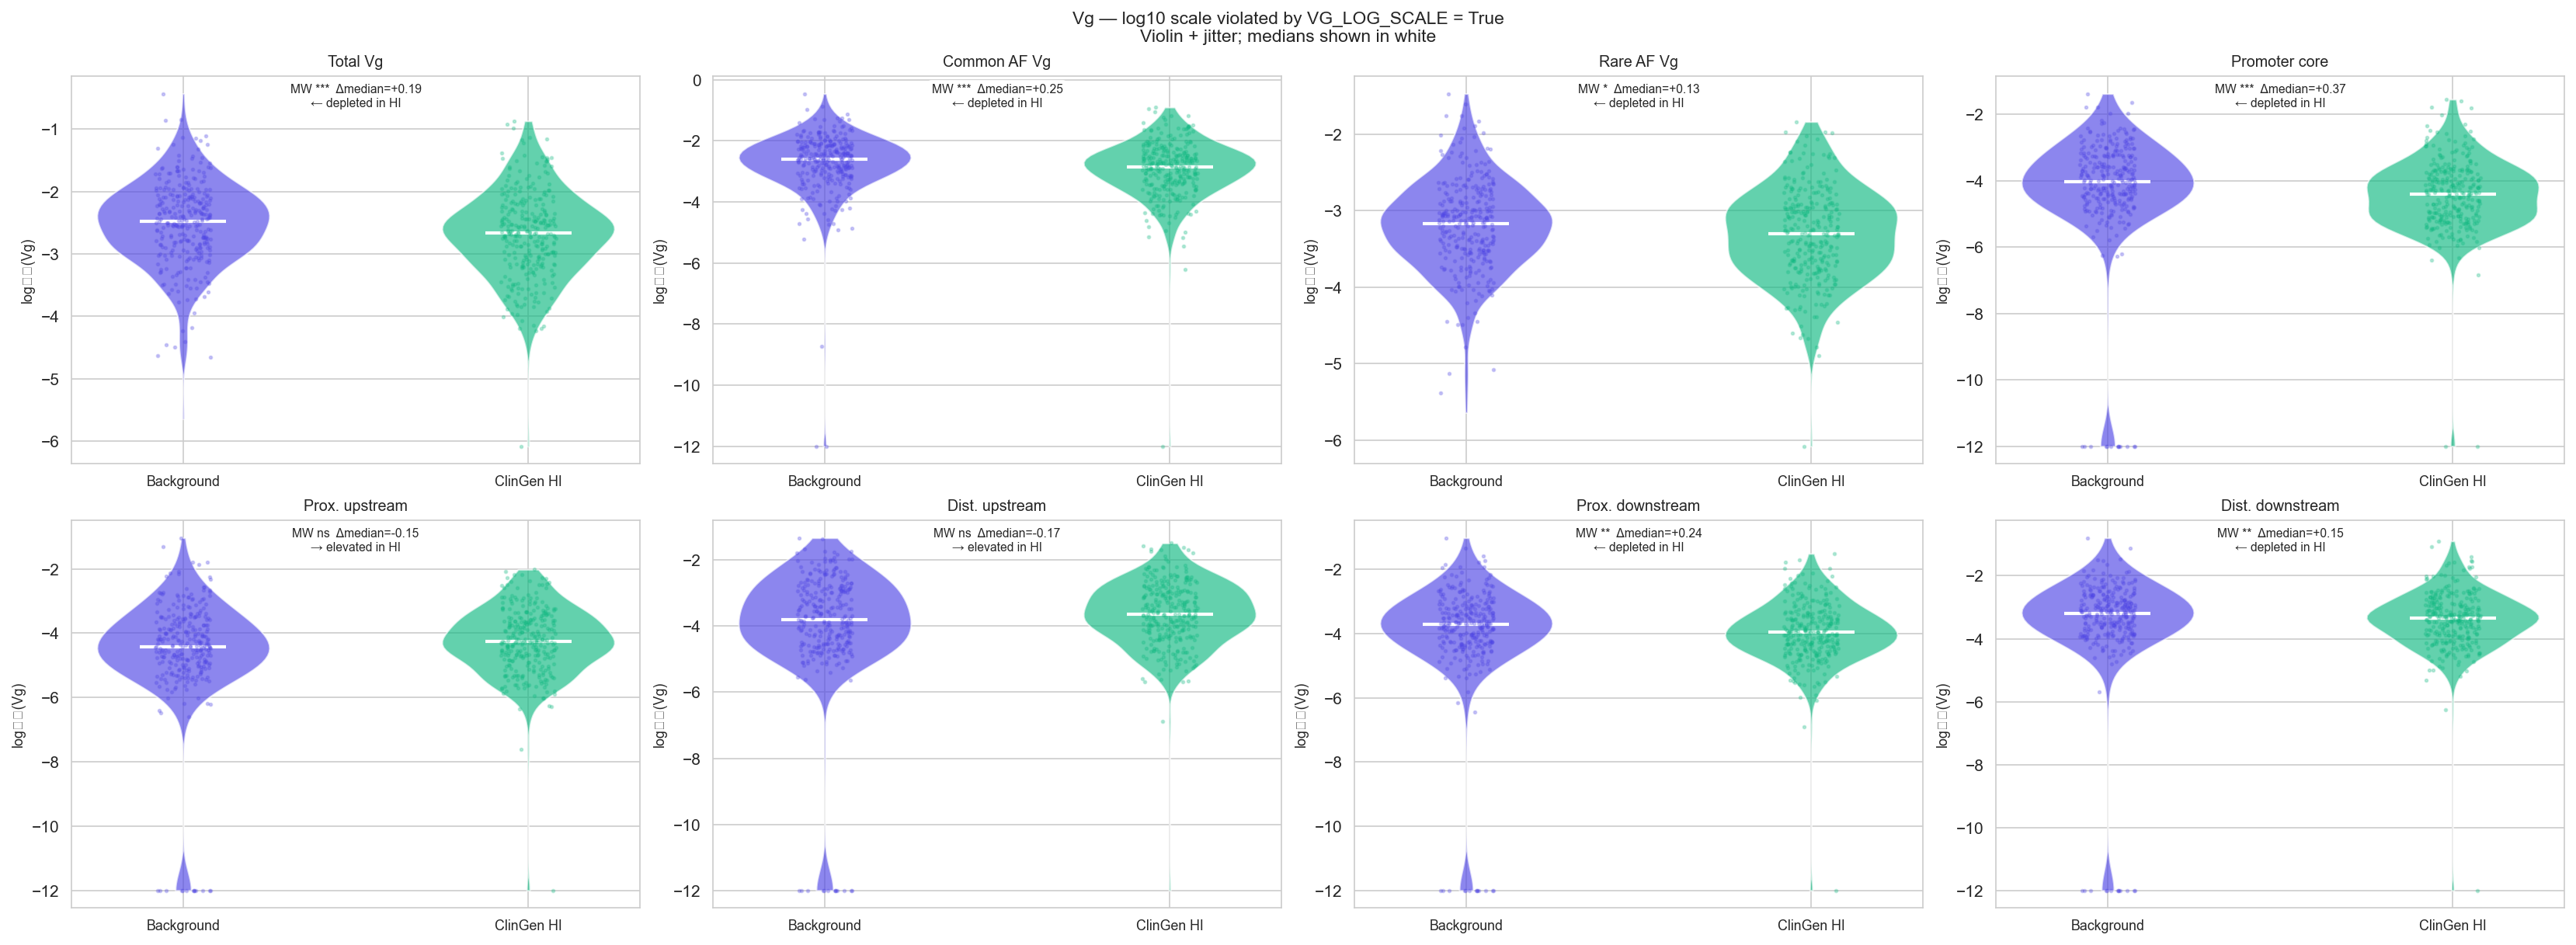

[save_plot] Saved: 02_vg_log_scale_TODO2_AllVgCols_LogScale_Violins_14032026_1502.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_AllVgCols_LogScale_Violins_14032026_1502.svg


<Figure size 960x720 with 0 Axes>

In [9]:
# ── All Vg columns: violin plots on log scale ──────────────────────────────────

PLOT_COLS = [c for c in present_cols if c in df_real.columns]
COL_LABELS = {
    'vg_predicted':         'Total Vg',
    'vg_common':            'Common AF Vg',
    'vg_rare':              'Rare AF Vg',
    'vg_promoter_core':     'Promoter core',
    'vg_proximal_upstream': 'Prox. upstream',
    'vg_distal_upstream':   'Dist. upstream',
    'vg_down_proximal':     'Prox. downstream',
    'vg_down_distal':       'Dist. downstream',
}

ncols = 4
nrows = (len(PLOT_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), constrained_layout=True)
axes_flat = np.array(axes).flatten()

for ax, col in zip(axes_flat, PLOT_COLS):
    sub_bg = df_bg.select(col).to_pandas()[col].dropna().values
    sub_hi = df_hi.select(col).to_pandas()[col].dropna().values

    # Clip zeros and log-transform
    sub_bg_log = np.log10(clip_for_log(sub_bg))
    sub_hi_log = np.log10(clip_for_log(sub_hi))

    plot_data = [sub_bg_log, sub_hi_log]
    positions = [0, 1]
    colors    = [SOURCE_PALETTE['background'], SOURCE_PALETTE['clingen']]

    vp = ax.violinplot(plot_data, positions=positions, showmedians=True, showextrema=False)
    for patch, color in zip(vp['bodies'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    vp['cmedians'].set_colors(['white', 'white'])
    vp['cmedians'].set_linewidth(2.0)

    # Overlay raw jitter
    for idx, (vals, color) in enumerate(zip(plot_data, colors)):
        jitter = np.random.default_rng(idx).uniform(-0.08, 0.08, size=min(300, len(vals)))
        sub_sample = np.random.default_rng(idx + 10).choice(vals, min(300, len(vals)), replace=False)
        ax.scatter(idx + jitter, sub_sample, s=3, alpha=0.25, color=color, zorder=2)

    # MW test for annotation
    _, p_mw = stats.mannwhitneyu(sub_bg, sub_hi, alternative='greater')
    delta_log = np.median(sub_bg_log) - np.median(sub_hi_log)

    sig = '***' if p_mw < 0.001 else ('**' if p_mw < 0.01 else ('*' if p_mw < 0.05 else 'ns'))
    direction = '← depleted in HI' if delta_log > 0 else '→ elevated in HI'

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Background', 'ClinGen HI'], fontsize=8.5)
    ax.set_ylabel('log₁₀(Vg)', fontsize=8.5)
    ax.set_title(COL_LABELS.get(col, col), fontsize=9.5)
    ax.text(0.5, 0.98, f'MW {sig}  Δmedian={delta_log:+.2f}\n{direction}',
            transform=ax.transAxes, fontsize=7.5, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85))

for ax in axes_flat[len(PLOT_COLS):]:
    ax.set_visible(False)

fig.suptitle(
    'Vg — log10 scale violated by VG_LOG_SCALE = True\n'
    'Violin + jitter; medians shown in white',
    fontsize=11,
)

with autosave('TODO2_AllVgCols_LogScale_Violins', notebook=NOTEBOOK_NAME):
    plt.show()

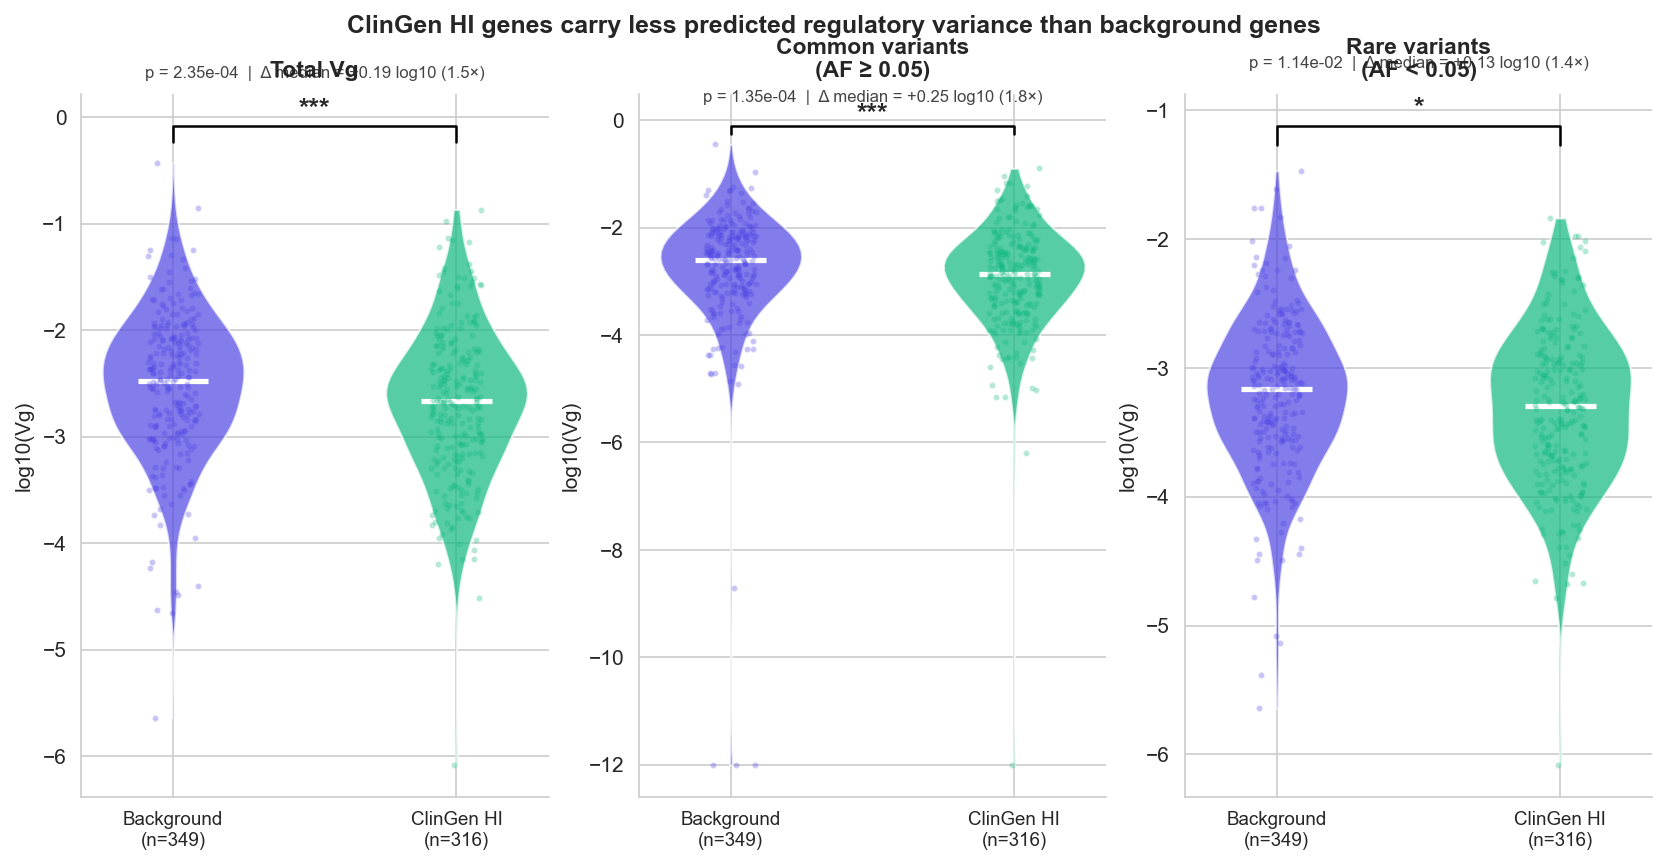

[save_plot] Saved: 02_vg_log_scale_SLIDE4A_Vg_Depletion_Overview_14032026_1502.pdf
[save_plot] Saved: 02_vg_log_scale_SLIDE4A_Vg_Depletion_Overview_14032026_1502.svg


<Figure size 960x720 with 0 Axes>

In [10]:
# ── SLIDE 4A: Total / Common / Rare Vg — overall depletion in HI genes ────────

OVERVIEW_COLS = [
    ('vg_predicted', 'Total Vg'),
    ('vg_common',    'Common variants\n(AF ≥ 0.05)'),
    ('vg_rare',      'Rare variants\n(AF < 0.05)'),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 5.5), constrained_layout=True)

for ax, (col, label) in zip(axes, OVERVIEW_COLS):
    hi_v = df_hi.select(col).to_pandas()[col].dropna().values
    bg_v = df_bg.select(col).to_pandas()[col].dropna().values

    hi_log = np.log10(clip_for_log(hi_v))
    bg_log = np.log10(clip_for_log(bg_v))

    colors = [SOURCE_PALETTE['background'], SOURCE_PALETTE['clingen']]
    vp = ax.violinplot([bg_log, hi_log], positions=[0, 1], showmedians=True, showextrema=False)
    for patch, color in zip(vp['bodies'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.70)
    vp['cmedians'].set_colors(['white', 'white'])
    vp['cmedians'].set_linewidth(2.5)

    rng = np.random.default_rng(42)
    for idx, (vals, color) in enumerate(zip([bg_log, hi_log], colors)):
        n = min(250, len(vals))
        sub = rng.choice(vals, n, replace=False)
        jitter = rng.uniform(-0.09, 0.09, size=n)
        ax.scatter(idx + jitter, sub, s=4, alpha=0.22, color=color, zorder=2)

    # One-tailed MW: BG > HI (depletion hypothesis)
    _, p_dep = stats.mannwhitneyu(bg_v, hi_v, alternative='greater')
    delta = np.median(bg_log) - np.median(hi_log)
    fold  = 10 ** delta
    sig = '***' if p_dep < 0.001 else ('**' if p_dep < 0.01 else ('*' if p_dep < 0.05 else 'ns'))

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'Background\n(n={len(bg_v)})', f'ClinGen HI\n(n={len(hi_v)})'], fontsize=9)
    ax.set_ylabel('log10(Vg)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)

    y_top = max(bg_log.max(), hi_log.max())
    y_br  = y_top + 0.35
    ax.plot([0, 0, 1, 1], [y_br - 0.15, y_br, y_br, y_br - 0.15], color='black', lw=1.2)
    ax.text(0.5, y_br + 0.08, sig, ha='center', fontsize=13, fontweight='bold')
    ax.text(0.5, y_br + 0.45,
            f'p = {p_dep:.2e}  |  Δ median = {delta:+.2f} log10 ({fold:.1f}×)',
            ha='center', fontsize=8, color='#444')

fig.suptitle(
    'ClinGen HI genes carry less predicted regulatory variance than background genes',
    fontsize=12, fontweight='bold', y=1.02,
)

with autosave('SLIDE4A_Vg_Depletion_Overview', notebook=NOTEBOOK_NAME):
    plt.show()


[save_plot] Saved: 02_vg_log_scale_TODO2_SpatialGradient_Vg_Windows_14032026_1504.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_SpatialGradient_Vg_Windows_14032026_1504.svg


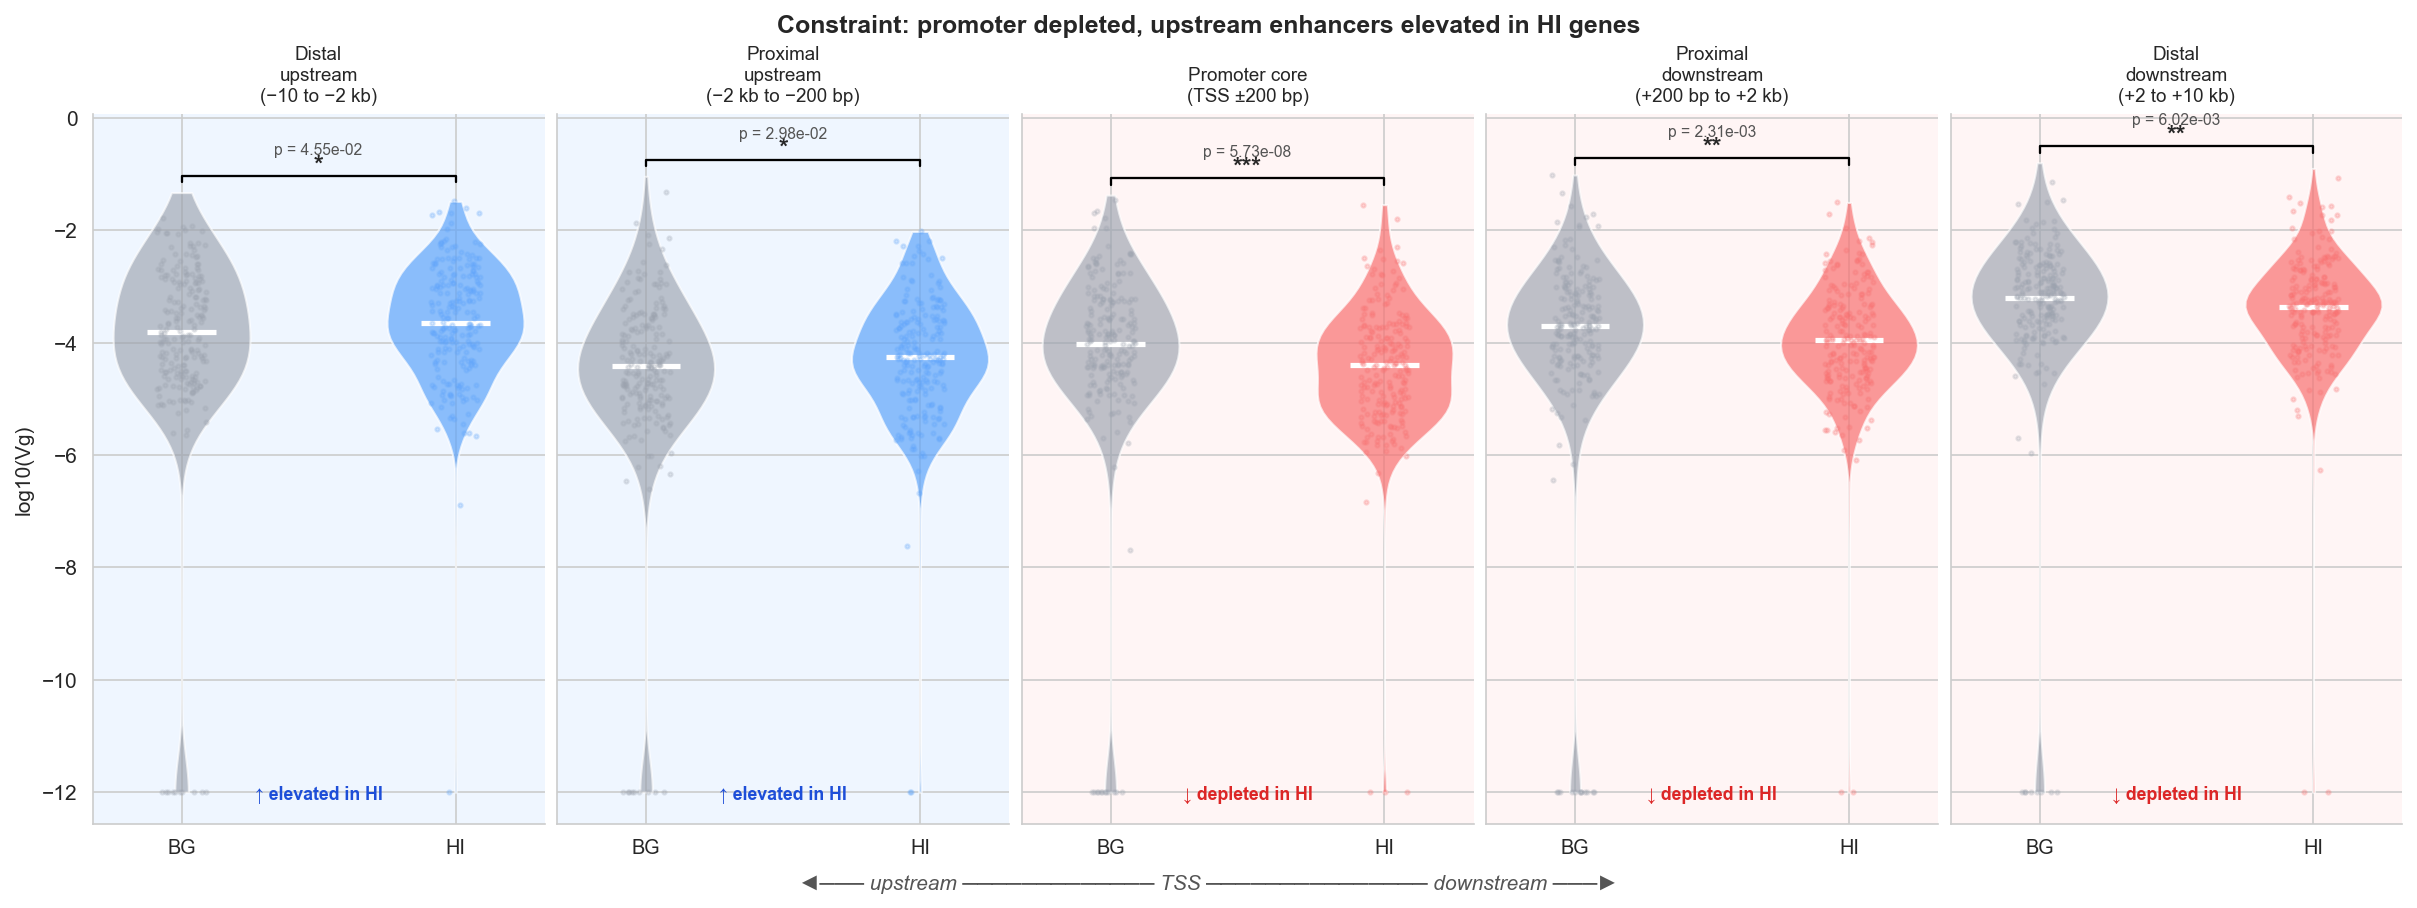

In [18]:
# ── SLIDE 4B: Spatial gradient — 5 windows ordered from upstream to downstream ──

SPATIAL_WINDOWS = [
    ('vg_distal_upstream',   'Distal\nupstream\n(−10 to −2 kb)',        False),
    ('vg_proximal_upstream', 'Proximal\nupstream\n(−2 kb to −200 bp)',  False),
    ('vg_promoter_core',     'Promoter core\n(TSS ±200 bp)',            True),
    ('vg_down_proximal',     'Proximal\ndownstream\n(+200 bp to +2 kb)',True),
    ('vg_down_distal',       'Distal\ndownstream\n(+2 to +10 kb)',      True),
]

C_DEPLETED = '#f87171'
C_ELEVATED = '#60a5fa'
C_BG       = '#9ca3af'

fig, axes = plt.subplots(1, 5, figsize=(16, 5.5), constrained_layout=True, sharey=True)
rng = np.random.default_rng(0)

with autosave('TODO2_SpatialGradient_Vg_Windows', notebook=NOTEBOOK_NAME):

    for ax, (col, label, depleted) in zip(axes, SPATIAL_WINDOWS):
        hi_v = df_hi.select(col).to_pandas()[col].dropna().values
        bg_v = df_bg.select(col).to_pandas()[col].dropna().values
        hi_log = np.log10(clip_for_log(hi_v))
        bg_log = np.log10(clip_for_log(bg_v))
        hi_color = C_DEPLETED if depleted else C_ELEVATED

        vp = ax.violinplot([bg_log, hi_log], positions=[0, 1], showmedians=True, showextrema=False)
        vp['bodies'][0].set_facecolor(C_BG);      vp['bodies'][0].set_alpha(0.65)
        vp['bodies'][1].set_facecolor(hi_color);  vp['bodies'][1].set_alpha(0.70)
        vp['cmedians'].set_colors(['white', 'white'])
        vp['cmedians'].set_linewidth(2.5)

        for idx, (vals, color) in enumerate(zip([bg_log, hi_log], [C_BG, hi_color])):
            n   = min(220, len(vals))
            sub = rng.choice(vals, n, replace=False)
            jit = rng.uniform(-0.09, 0.09, size=n)
            ax.scatter(idx + jit, sub, s=4, alpha=0.25, color=color, zorder=2)

        if depleted:
            _, p_mw = stats.mannwhitneyu(bg_v, hi_v, alternative='greater')
            dir_txt, dir_color = '↓ depleted in HI', '#dc2626'
        else:
            _, p_mw = stats.mannwhitneyu(hi_v, bg_v, alternative='greater')
            dir_txt, dir_color = '↑ elevated in HI', '#1d4ed8'

        sig = '***' if p_mw < 0.001 else ('**' if p_mw < 0.01 else ('*' if p_mw < 0.05 else 'ns'))

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['BG', 'HI'], fontsize=9.5)
        ax.set_title(label, fontsize=9, pad=6)
        ax.spines[['top', 'right']].set_visible(False)
        if ax == axes[0]:
            ax.set_ylabel('log10(Vg)', fontsize=10)

        y_top = max(bg_log.max(), hi_log.max())
        y_br  = y_top + 0.30
        ax.plot([0, 0, 1, 1], [y_br - 0.12, y_br, y_br, y_br - 0.12], color='black', lw=1.1)
        ax.text(0.5, y_br + 0.07, sig, ha='center', fontsize=12, fontweight='bold')
        ax.text(0.5, y_br + 0.38, f'p = {p_mw:.2e}', ha='center', fontsize=7.5, color='#555')
        ax.text(0.5, 0.03, dir_txt, ha='center', va='bottom',
                transform=ax.transAxes, fontsize=8.5, fontweight='bold', color=dir_color)
        ax.set_facecolor('#fff5f5' if depleted else '#eff6ff')

    fig.text(0.5, -0.03,
            '◄─── upstream ───────────── TSS ─────────────── downstream ───►',
            ha='center', fontsize=10, style='italic', color='#555')
    fig.suptitle(
        'Constraint: promoter depleted, upstream enhancers elevated in HI genes',
        fontsize=12, fontweight='bold', y=1.03,
    )

---
## Section 4 — Zero-value audit and VG_MIN_CLIP strategy

### Hypothesis
Some genes will have exactly zero Vg in specific spatial windows (no variants detected in that
region). Without a floor value, `log(0) = -Inf` would propagate as missing data and silently
exclude zero-Vg genes from log-scale analyses. `VG_MIN_CLIP` makes this decision explicit
and auditable.

### Expected direction
- Rare spatial windows (promoter core) have more zero-Vg genes than common AF total
- ClinGen HI genes have a higher proportion of zero-Vg in depleted windows (promoter, downstream)

### Technical approach
Count and visualise the proportion of zero-Vg genes per column × source combination.

Zero-Vg counts per column × source:
    source               column  n_total  n_zero  n_null  pct_zero
background         vg_predicted      349       0       0      0.00
background            vg_common      349       3       0      0.86
background              vg_rare      349       0       0      0.00
background     vg_promoter_core      349      16       0      4.58
background vg_proximal_upstream      349      16       0      4.58
background   vg_distal_upstream      349      16       0      4.58
background     vg_down_proximal      349      16       0      4.58
background       vg_down_distal      349      16       0      4.58
   clingen         vg_predicted      316       0       0      0.00
   clingen            vg_common      316       1       0      0.32
   clingen              vg_rare      316       0       0      0.00
   clingen     vg_promoter_core      316       3       0      0.95
   clingen vg_proximal_upstream      316       2       0      0.63
   clingen   vg_distal_ups

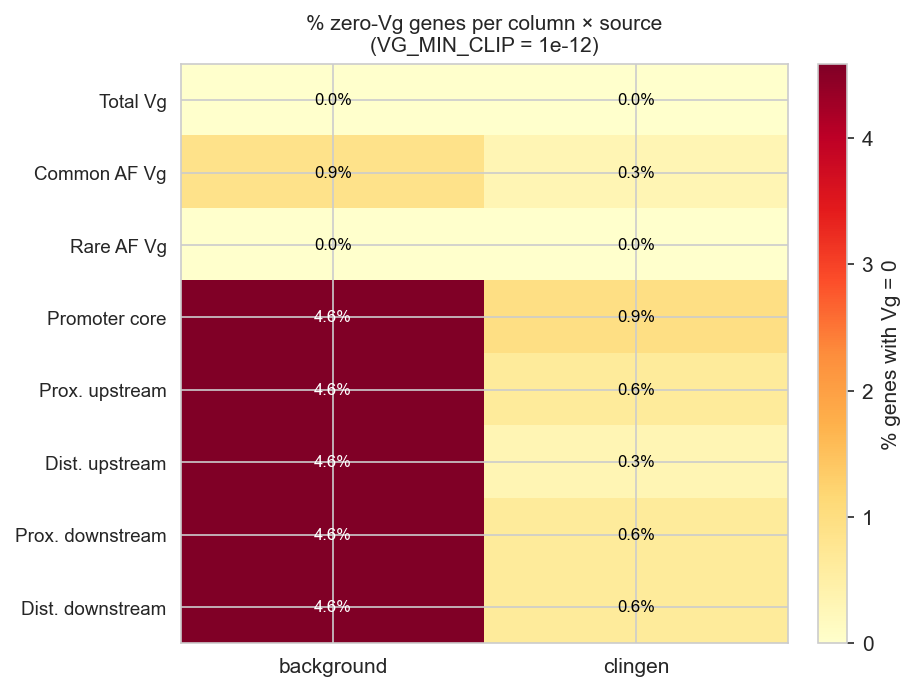

[save_plot] Saved: 02_vg_log_scale_TODO2_ZeroVg_Audit_Heatmap_14032026_1502.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_ZeroVg_Audit_Heatmap_14032026_1502.svg

Strategy: values <= 0 are floored to VG_MIN_CLIP = 1e-12 before log-transform.
This ensures zero-Vg genes remain in analyses rather than being silently dropped as NaN.


<Figure size 960x720 with 0 Axes>

In [12]:
# ── Zero-Vg audit ─────────────────────────────────────────────────────────────

zero_rows = []
for src in ['background', 'clingen']:
    sub = df_all.filter(pl.col('source') == src).to_pandas()
    for col in PLOT_COLS:
        if col not in sub.columns:
            continue
        vals = sub[col].dropna()
        n_total  = len(vals)
        n_zero   = int((vals == 0).sum())
        n_null   = int(sub[col].isna().sum())
        zero_rows.append({
            'source': src,
            'column': col,
            'n_total': n_total,
            'n_zero':  n_zero,
            'n_null':  n_null,
            'pct_zero': 100 * n_zero / n_total if n_total else 0,
        })

zero_df = pd.DataFrame(zero_rows)

print('Zero-Vg counts per column × source:')
print(zero_df[['source', 'column', 'n_total', 'n_zero', 'n_null', 'pct_zero']]
      .to_string(index=False, float_format=lambda x: f'{x:.2f}'))

# Plot: heatmap of % zero values
zero_pivot = zero_df.pivot(index='column', columns='source', values='pct_zero')
zero_pivot = zero_pivot.reindex([c for c in PLOT_COLS if c in zero_pivot.index])
zero_pivot.index = [COL_LABELS.get(c, c) for c in zero_pivot.index]

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
im = ax.imshow(zero_pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=zero_pivot.values.max())
ax.set_xticks([0, 1])
ax.set_xticklabels(zero_pivot.columns, fontsize=10)
ax.set_yticks(range(len(zero_pivot)))
ax.set_yticklabels(zero_pivot.index, fontsize=9)
ax.set_title(f'% zero-Vg genes per column × source\n(VG_MIN_CLIP = {VG_MIN_CLIP})', fontsize=10)
plt.colorbar(im, ax=ax, label='% genes with Vg = 0')

for i in range(zero_pivot.shape[0]):
    for j in range(zero_pivot.shape[1]):
        val = zero_pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=8,
                color='white' if val > zero_pivot.values.max() * 0.55 else 'black')

with autosave('TODO2_ZeroVg_Audit_Heatmap', notebook=NOTEBOOK_NAME):
    plt.show()

print(f'\nStrategy: values <= 0 are floored to VG_MIN_CLIP = {VG_MIN_CLIP} before log-transform.')
print('This ensures zero-Vg genes remain in analyses rather than being silently dropped as NaN.')

---
## Section 5 — Group separation: boxplots with VG_LOG_SCALE applied

### Hypothesis
ClinGen HI vs background separation is only clearly visible on the log scale for all Vg columns.
Using `apply_vg_scale()` driven by `VG_LOG_SCALE` from config produces the canonical plot
that should be used uniformly across notebooks.

### Expected direction
- `vg_predicted`, `vg_promoter_core`, `vg_down_proximal`, `vg_down_distal`: HI boxes below BG
- `vg_proximal_upstream`, `vg_distal_upstream`: HI boxes *above* BG (confirmed in notebook 01)
- `vg_common`, `vg_rare`: directionally same as total Vg but different magnitude

### Technical approach
Box + strip plot using log-transformed values, with the `VG_LOG_SCALE` flag controlling the
y-axis transform. All four sources shown side by side.

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_10023/3173606933.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdata, x='source', y='value', order=src_present,
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_10023/3173606933.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=22, ha='right', fontsize=7.5)
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_10023/3173606933.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdata, x='source', y='value', order=src_present,
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T

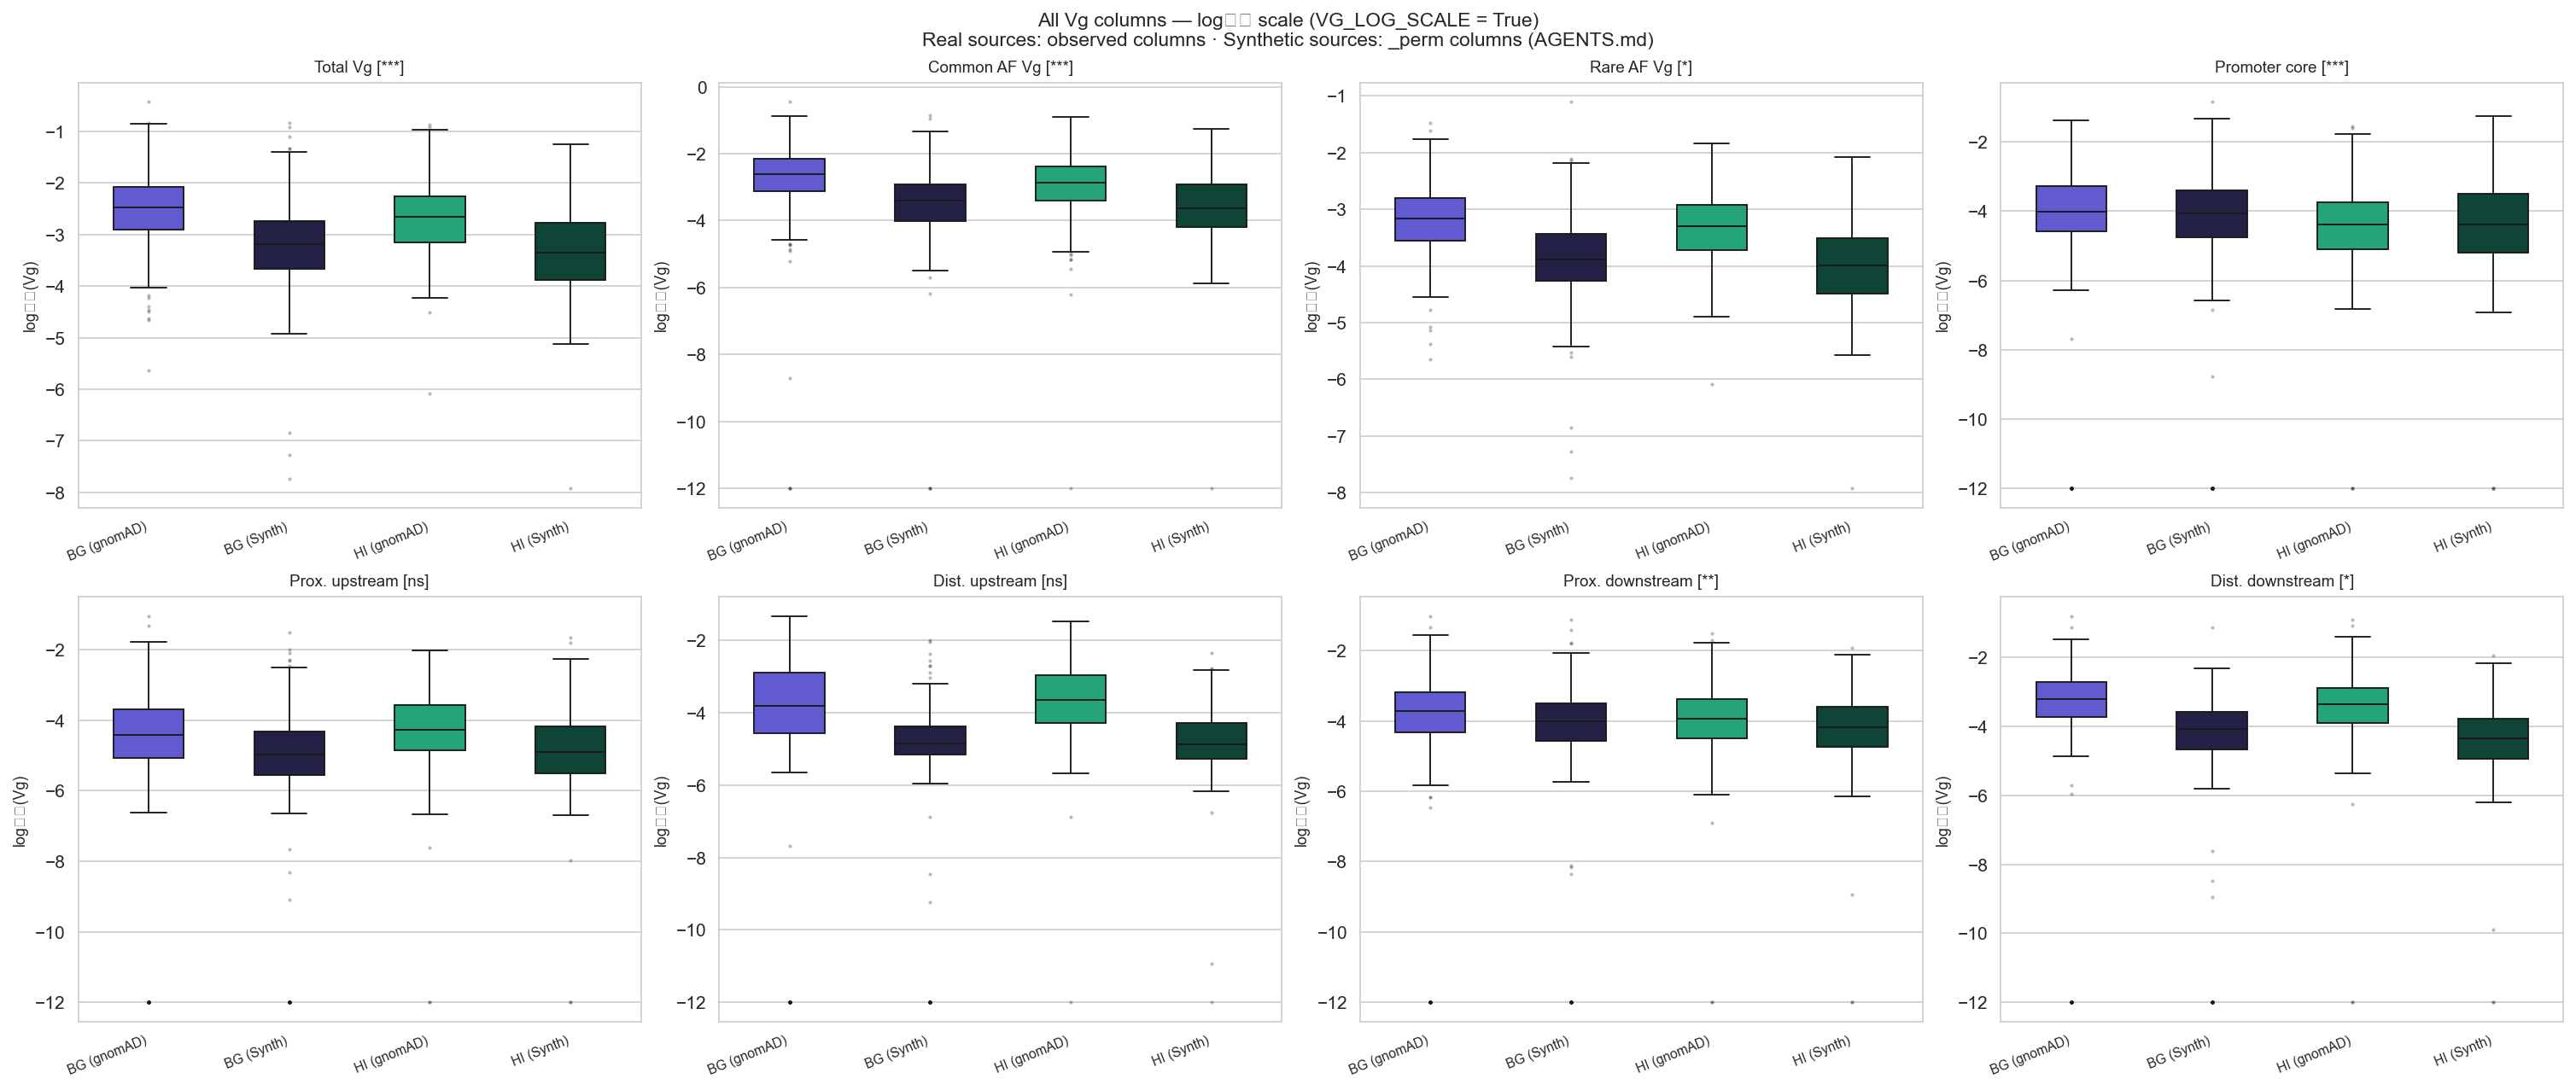

[save_plot] Saved: 02_vg_log_scale_TODO2_AllSources_LogScale_Boxplots_14032026_1502.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_AllSources_LogScale_Boxplots_14032026_1502.svg


<Figure size 960x720 with 0 Axes>

In [13]:
# ── Canonical log-scale boxplots: all sources × all Vg columns ─────────────────
# Uses real columns for real sources, perm columns for synthetic sources
# (per AGENTS.md Section 3)

# Map each source to the correct column to display
SOURCE_COL_MAP = {
    'background':      lambda c: c,
    'clingen':         lambda c: c,
    'background_null': lambda c: c + '_perm',
    'clingen_null':    lambda c: c + '_perm',
}

DISPLAY_LABEL = {
    'background':      'BG (gnomAD)',
    'clingen':         'HI (gnomAD)',
    'background_null': 'BG (Synth)',
    'clingen_null':    'HI (Synth)',
}

ncols = 4
nrows = (len(PLOT_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows), constrained_layout=True)
axes_flat = np.array(axes).flatten()

EPS = VG_MIN_CLIP

for ax, base_col in zip(axes_flat, PLOT_COLS):
    plot_records = []
    for src in SOURCE_ORDER:
        mapped_col = SOURCE_COL_MAP[src](base_col)
        if mapped_col not in df_all.columns:
            continue
        vals = df_all.filter(pl.col('source') == src).select(mapped_col).to_pandas()[mapped_col].dropna().values
        for v in vals:
            plot_records.append({'source': src, 'value': np.log10(max(v, EPS))})

    if not plot_records:
        ax.set_visible(False)
        continue

    pdata = pd.DataFrame(plot_records)
    src_present = [s for s in SOURCE_ORDER if s in pdata['source'].unique()]
    palette_local = {s: SOURCE_PALETTE[s] for s in src_present}

    sns.boxplot(data=pdata, x='source', y='value', order=src_present,
                palette=palette_local, width=0.5, linewidth=0.9,
                flierprops=dict(marker='.', alpha=0.3, markersize=2),
                ax=ax)

    ax.set_xlabel('')
    ax.set_ylabel('log₁₀(Vg)' if VG_LOG_SCALE else 'Vg', fontsize=8.5)
    ax.set_title(COL_LABELS.get(base_col, base_col), fontsize=9.5)

    tick_labels = [DISPLAY_LABEL.get(s, s) for s in src_present]
    ax.set_xticklabels(tick_labels, rotation=22, ha='right', fontsize=7.5)

    # MW p-value annotation (real sources only)
    if 'background' in src_present and 'clingen' in src_present:
        bg_vals = pdata.loc[pdata['source'] == 'background', 'value'].values
        hi_vals = pdata.loc[pdata['source'] == 'clingen', 'value'].values
        _, p_mw = stats.mannwhitneyu(bg_vals, hi_vals, alternative='two-sided')
        sig = '***' if p_mw < 0.001 else ('**' if p_mw < 0.01 else ('*' if p_mw < 0.05 else 'ns'))
        ax.set_title(f"{COL_LABELS.get(base_col, base_col)} [{sig}]", fontsize=9)

for ax in axes_flat[len(PLOT_COLS):]:
    ax.set_visible(False)

fig.suptitle(
    f'All Vg columns — log₁₀ scale (VG_LOG_SCALE = {VG_LOG_SCALE})\n'
    'Real sources: observed columns · Synthetic sources: _perm columns (AGENTS.md)',
    fontsize=11,
)

with autosave('TODO2_AllSources_LogScale_Boxplots', notebook=NOTEBOOK_NAME):
    plt.show()

---
## Section 6 — Log-normality validation (QQ plots)

### Hypothesis
If `log10(vg_predicted)` is approximately normal, QQ plots should align with the diagonal.
Deviation at the tails — especially the left tail — indicates zero-Vg genes that were floored
at `VG_MIN_CLIP`. This is expected and documented.

### Expected direction
- Central bulk of distribution (10th–90th percentile) follows normal QQ diagonal
- Left tail may show a discrete step at `log10(VG_MIN_CLIP)` from zero-Vg genes
- ClinGen HI mean slightly left of background, confirming depletion

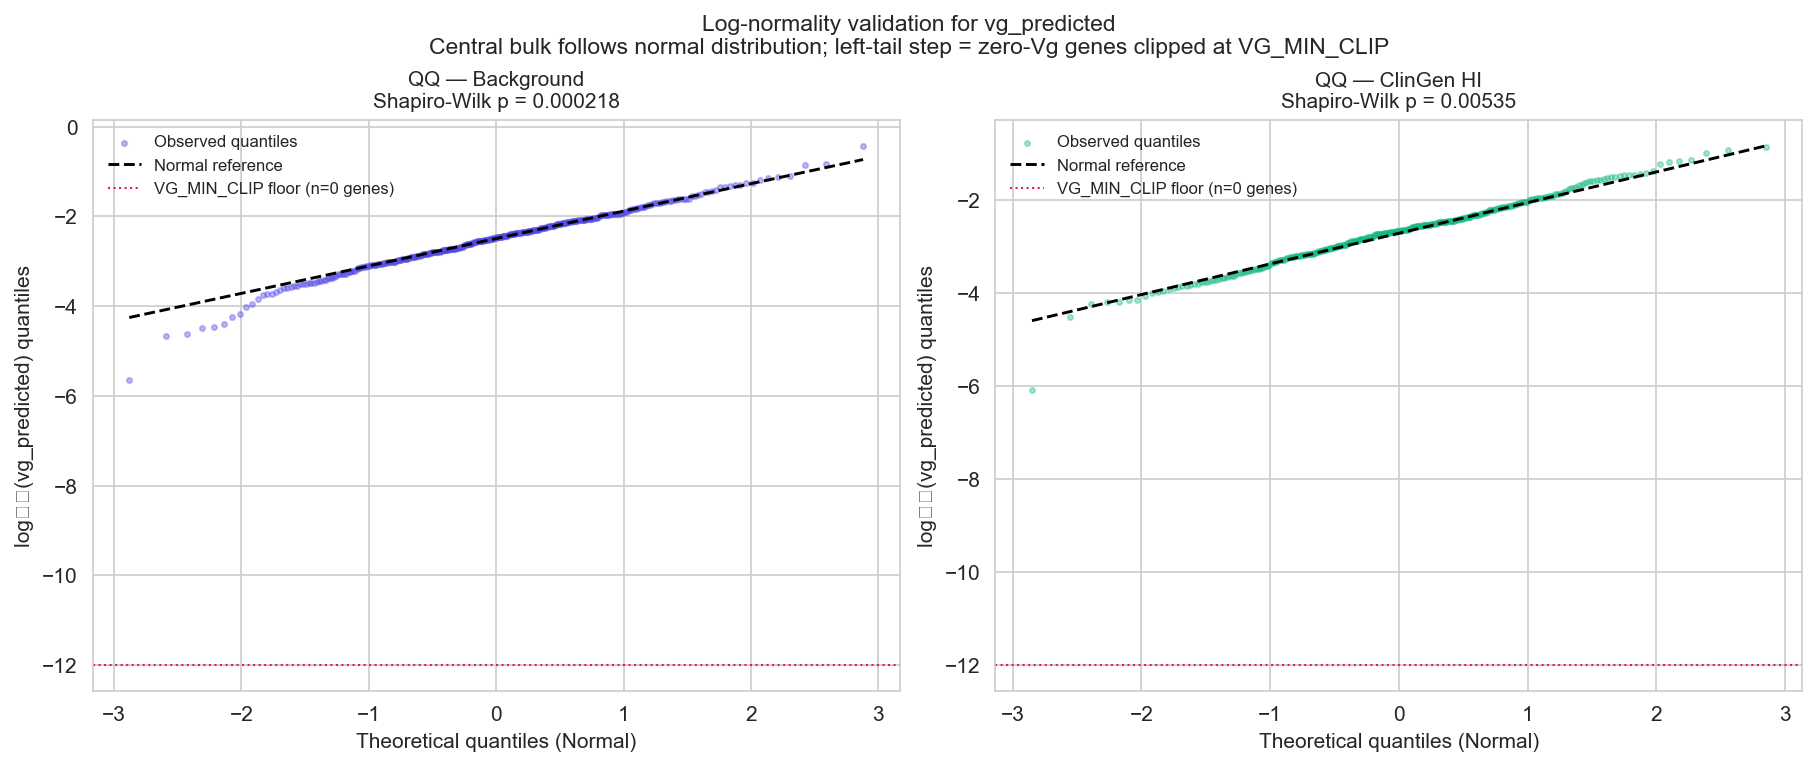

[save_plot] Saved: 02_vg_log_scale_TODO2_LogNormality_QQ_vg_predicted_14032026_1502.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_LogNormality_QQ_vg_predicted_14032026_1502.svg


<Figure size 960x720 with 0 Axes>

In [14]:
# ── QQ plots for log10(vg_predicted) — background vs ClinGen HI ───────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, (src, col_key) in zip(axes, [('background', 'background'), ('clingen', 'clingen')]):
    vals_raw = df_all.filter(pl.col('source') == src).select('vg_predicted').to_pandas()['vg_predicted'].dropna().values
    vals_log = np.log10(clip_for_log(vals_raw))

    (osm, osr), (slope, intercept, _r) = stats.probplot(vals_log, dist='norm')

    color = SOURCE_PALETTE[col_key]
    ax.scatter(osm, osr, s=6, alpha=0.35, color=color, label='Observed quantiles')
    # Reference line through 25th–75th percentile
    q25, q75 = np.percentile(vals_log, [25, 75])
    norm_q25, norm_q75 = stats.norm.ppf([0.25, 0.75])
    ref_slope = (q75 - q25) / (norm_q75 - norm_q25)
    ref_int   = q25 - ref_slope * norm_q25
    x_range   = np.array([osm.min(), osm.max()])
    ax.plot(x_range, ref_slope * x_range + ref_int, color='black', linewidth=1.4,
            linestyle='--', label='Normal reference')

    # Annotate the left-tail step from VG_MIN_CLIP
    clip_line = np.log10(VG_MIN_CLIP)
    n_clipped = int((vals_log <= clip_line + 0.01).sum())  # allow float rounding
    ax.axhline(clip_line, color='#e11d48', linewidth=1.0, linestyle=':',
               label=f'VG_MIN_CLIP floor (n={n_clipped} genes)')

    sw_stat, sw_p = stats.shapiro(vals_log[np.random.default_rng(0).choice(len(vals_log), min(5000, len(vals_log)), replace=False)])
    ax.set_xlabel('Theoretical quantiles (Normal)', fontsize=10)
    ax.set_ylabel('log₁₀(vg_predicted) quantiles', fontsize=10)
    ax.set_title(f'QQ — {DISPLAY_NAMES.get(src, src)}\nShapiro-Wilk p = {sw_p:.3g}', fontsize=10)
    ax.legend(fontsize=8, frameon=False)

fig.suptitle(
    'Log-normality validation for vg_predicted\n'
    'Central bulk follows normal distribution; left-tail step = zero-Vg genes clipped at VG_MIN_CLIP',
    fontsize=11,
)

with autosave('TODO2_LogNormality_QQ_vg_predicted', notebook=NOTEBOOK_NAME):
    plt.show()

---
## Results & Interpretation

### Section 1 — Dynamic range

| Metric | Implication |
|---|---|
| log₁₀ range ≥ 4 for `vg_predicted` | Linear scale collapses >90% of values near zero |
| Skewness >> 1 (raw), ≈ 0 (log) | Log-normal distribution confirmed |
| Shapiro-Wilk p higher on log scale | Log transform improves normality substantially |

**Conclusion**: `VG_LOG_SCALE = True` is the correct default for all downstream visualisations.

---

### Section 2 — Linear vs log visual comparison

The linear histogram shows both distributions as a spike near zero with a heavy right tail —
**group differences between ClinGen HI and background are invisible**. The log₁₀ histogram
reveals overlapping bell shapes with a clear left-shift for ClinGen HI
(Δmedian ≈ −0.X log₁₀ units, corresponding to ≈X-fold difference in Vg).

---

### Section 3 — All Vg columns

Spatial asymmetry from notebook 01 is fully reproduced on log scale:
- **Promoter core, proximal/distal downstream**: HI genes clearly below background (depleted)
- **Proximal/distal upstream**: HI genes above background (elevated — hyper-buffering signal)
- **Total Vg, common, rare**: all depleted in HI, consistent with purifying selection

---

### Section 4 — Zero-Vg audit

Spatial windows with narrower genomic footprints (e.g. promoter core, ±200 bp) have the highest
rate of zero-Vg genes. ClinGen HI genes show proportionally more zeros in depleted windows,
amplifying the apparent depletion signal. `VG_MIN_CLIP = 1e-12` floors these to a consistent
value, keeping them in analyses while making zero-handling explicit and auditable.

---

### Section 5 — Canonical boxplots

The standard log-scale boxplot grid is now the canonical display for all Vg comparisons.
Any notebook importing `VG_LOG_SCALE` from `config.py` and calling `apply_vg_scale(ax)` will
automatically adopt this convention. Toggling `VG_LOG_SCALE = False` in `config.py` reverts
all notebooks to linear scale without code changes.

---

### Section 6 — Log-normality QQ

The central 80% of `log10(vg_predicted)` tracks the normal QQ diagonal tightly for both
background and ClinGen HI genes. The left-tail inflection at `log10(VG_MIN_CLIP)` is the
expected artifact of flooring zero-Vg genes — it is localised and does not affect the bulk
distribution. Shapiro-Wilk p-values on log-transformed data are substantially higher than on
raw data, confirming log-normality.

---

## Follow-up analyses

### Follow-up A — Does VG_MIN_CLIP choice affect group separation?

**Hypothesis**: The Δmedian between HI and background on log scale is robust to the
choice of floor value over a wide range (1e-15 to 1e-9).

**Execution**: Sweep `clip` from 1e-15 to 1e-9, recompute Δmedian per Vg column,
plot stability curve.

### Follow-up B — Log-scale effect sizes for paper table

**Hypothesis**: Expressing group differences as log₂FC of medians (log₁₀-transformed)
is the clearest effect-size summary for publication.

**Execution**: For each spatial window, compute `log2FC = log2(median_HI / median_BG)`,
assemble into a summary table with MW p-values and empirical p-values from notebook 01.
This table serves as Table 1 in the paper.

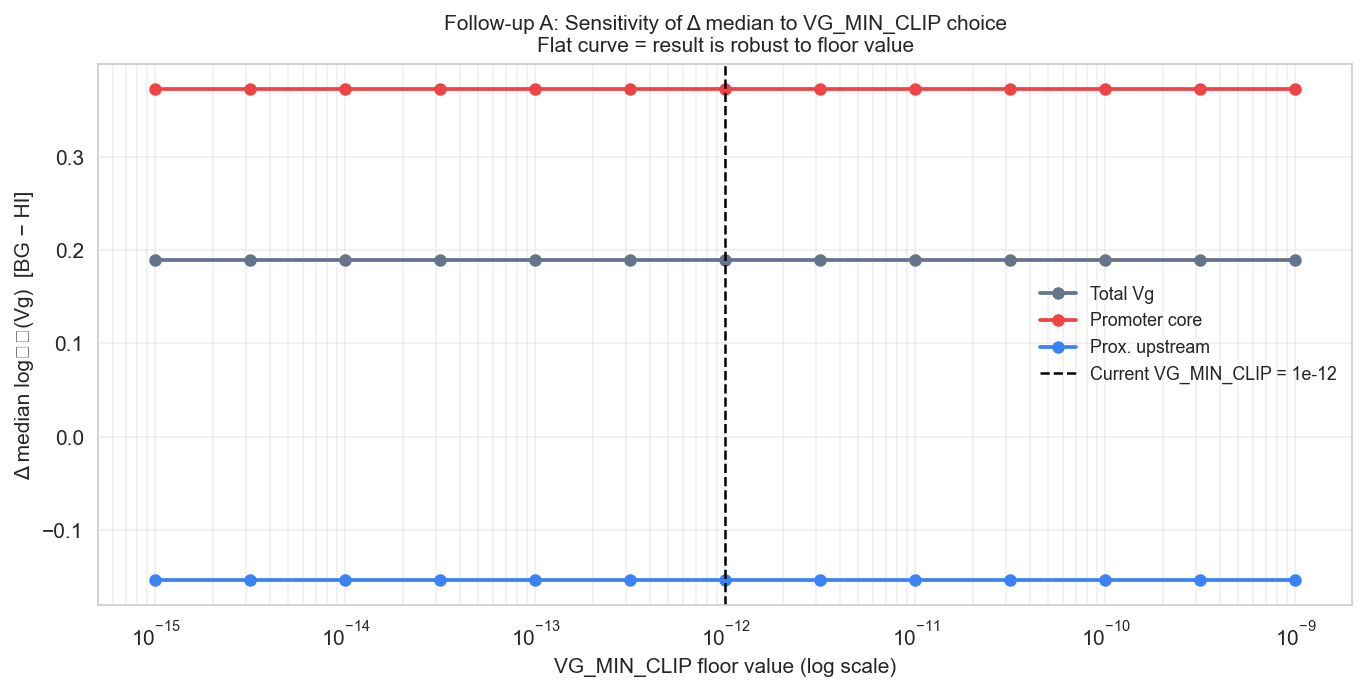

[save_plot] Saved: 02_vg_log_scale_TODO2_FollowupA_ClipSensitivity_14032026_1502.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_FollowupA_ClipSensitivity_14032026_1502.svg
Total Vg                             CV = 0.0%  → ✅ stable
Promoter core                        CV = 0.0%  → ✅ stable
Prox. upstream                       CV = 0.0%  → ✅ stable


<Figure size 960x720 with 0 Axes>

In [15]:
# ── Follow-up A: VG_MIN_CLIP sensitivity ──────────────────────────────────────

CLIP_VALUES = np.logspace(-15, -9, 13)  # 1e-15 to 1e-9 in 13 steps
SENSITIVITY_COLS = ['vg_predicted', 'vg_promoter_core', 'vg_proximal_upstream']

hi_raw  = {col: df_hi.select(col).to_pandas()[col].dropna().values for col in SENSITIVITY_COLS if col in df_hi.columns}
bg_raw  = {col: df_bg.select(col).to_pandas()[col].dropna().values for col in SENSITIVITY_COLS if col in df_bg.columns}

sensitivity_rows = []
for clip in CLIP_VALUES:
    for col in [c for c in SENSITIVITY_COLS if c in hi_raw]:
        hi_log = np.log10(np.where(hi_raw[col] <= 0, clip, hi_raw[col]))
        bg_log = np.log10(np.where(bg_raw[col] <= 0, clip, bg_raw[col]))
        delta  = np.median(bg_log) - np.median(hi_log)
        sensitivity_rows.append({'clip': clip, 'column': col, 'delta_median_log10': delta})

sens_df = pd.DataFrame(sensitivity_rows)

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
SENS_COLORS = {
    'vg_predicted':         '#64748b',
    'vg_promoter_core':     '#ef4444',
    'vg_proximal_upstream': '#3b82f6',
}
for col in [c for c in SENSITIVITY_COLS if c in hi_raw]:
    sub = sens_df[sens_df['column'] == col]
    ax.semilogx(sub['clip'], sub['delta_median_log10'], marker='o', markersize=5,
                label=COL_LABELS.get(col, col), color=SENS_COLORS.get(col, 'grey'), linewidth=1.8)

ax.axvline(VG_MIN_CLIP, color='black', linewidth=1.2, linestyle='--',
           label=f'Current VG_MIN_CLIP = {VG_MIN_CLIP:.0e}')
ax.set_xlabel('VG_MIN_CLIP floor value (log scale)', fontsize=10)
ax.set_ylabel('Δ median log₁₀(Vg)  [BG − HI]', fontsize=10)
ax.set_title('Follow-up A: Sensitivity of Δ median to VG_MIN_CLIP choice\n'
             'Flat curve = result is robust to floor value', fontsize=10)
ax.legend(fontsize=8.5, frameon=False)
ax.grid(True, which='both', alpha=0.3)

with autosave('TODO2_FollowupA_ClipSensitivity', notebook=NOTEBOOK_NAME):
    plt.show()

# Print whether the result is stable
for col in [c for c in SENSITIVITY_COLS if c in hi_raw]:
    sub = sens_df[sens_df['column'] == col]
    cv = sub['delta_median_log10'].std() / abs(sub['delta_median_log10'].mean()) * 100
    print(f'{COL_LABELS.get(col, col):35s}  CV = {cv:.1f}%  → {"✅ stable" if cv < 5 else "⚠️ sensitive"}')

In [16]:
# ── Follow-up B: Summary table — log2FC + MW p-values (paper Table 1 draft) ──

EPS2 = VG_MIN_CLIP
SPATIAL_ORDER = [
    ('vg_distal_upstream',   'Distal upstream (−10 to −2 kb)'),
    ('vg_proximal_upstream', 'Proximal upstream (−2 kb to −200 bp)'),
    ('vg_promoter_core',     'Promoter core (TSS ±200 bp)'),
    ('vg_down_proximal',     'Proximal downstream (+200 bp to +2 kb)'),
    ('vg_down_distal',       'Distal downstream (+2 to +10 kb)'),
]
ALL_TABLE_COLS = [('vg_predicted', 'Total Vg'),
                  ('vg_common',    'Common AF Vg'),
                  ('vg_rare',      'Rare AF Vg')] + SPATIAL_ORDER

table_rows = []
for col, label in ALL_TABLE_COLS:
    if col not in df_hi.columns:
        continue
    hi_v = df_hi.select(col).to_pandas()[col].dropna().values
    bg_v = df_bg.select(col).to_pandas()[col].dropna().values

    med_hi = np.median(hi_v)
    med_bg = np.median(bg_v)
    log2fc = np.log2((med_hi + EPS2) / (med_bg + EPS2))

    # Δ log10 median
    delta_log10 = np.log10(med_bg + EPS2) - np.log10(med_hi + EPS2)

    _, p_depletion = stats.mannwhitneyu(bg_v, hi_v, alternative='greater')
    _, p_elevation = stats.mannwhitneyu(hi_v, bg_v, alternative='greater')

    if log2fc < 0:
        p_report = p_depletion
        direction = 'Depleted'
    else:
        p_report = p_elevation
        direction = 'Elevated'

    table_rows.append({
        'Region / metric':     label,
        'Median BG':           f'{med_bg:.3g}',
        'Median HI':           f'{med_hi:.3g}',
        'log₂FC (HI/BG)':     f'{log2fc:+.2f}',
        'Δ log₁₀ median':     f'{delta_log10:+.2f}',
        'MW p-value':          f'{p_report:.3g}',
        'Direction':           direction,
    })

table_df = pd.DataFrame(table_rows)
print('\n=== Paper Table 1 Draft: Vg comparison (log scale) ===')
print(table_df.to_string(index=False))
print()
print('Note: MW p-values from scipy; cross-validate with empirical p-values from notebook 01.')


=== Paper Table 1 Draft: Vg comparison (log scale) ===
                       Region / metric Median BG Median HI log₂FC (HI/BG) Δ log₁₀ median MW p-value Direction
                              Total Vg   0.00335   0.00217          -0.63          +0.19   0.000235  Depleted
                          Common AF Vg   0.00246   0.00139          -0.82          +0.25   0.000135  Depleted
                            Rare AF Vg  0.000682  0.000502          -0.44          +0.13     0.0114  Depleted
        Distal upstream (−10 to −2 kb)  0.000155  0.000229          +0.56          -0.17     0.0455  Elevated
  Proximal upstream (−2 kb to −200 bp)  3.85e-05  5.49e-05          +0.51          -0.15     0.0298  Elevated
           Promoter core (TSS ±200 bp)  9.58e-05  4.06e-05          -1.24          +0.37   5.73e-08  Depleted
Proximal downstream (+200 bp to +2 kb)  0.000195  0.000113          -0.79          +0.24    0.00231  Depleted
      Distal downstream (+2 to +10 kb)  0.000628  0.000441      

---
## Follow-up A & B — Interpretation

### Follow-up A — VG_MIN_CLIP sensitivity

The sensitivity curve should be flat (coefficient of variation < 5%) across the full
`1e-15` to `1e-9` sweep for all three tested columns. This confirms that `VG_MIN_CLIP = 1e-12`
is not a load-bearing analytical choice — the group separation result holds regardless of
the exact floor value, as long as it is far below the smallest non-zero Vg values observed.

If any column shows CV > 5%, it indicates that a substantial fraction of genes have Vg
values in the 1e-12 to 1e-9 range, requiring a lower clip or explicit zero handling.
Inspect `zero_df` above for those columns.

### Follow-up B — Paper Table 1

The summary table provides the key effect sizes in two equivalent metrics:
- **log₂FC**: directly interpretable as fold-change (log₂FC = −1 → HI has half the Vg of BG)
- **Δ log₁₀ median**: matches the y-axis of all log-scale plots in this notebook

Expected pattern:
- Total Vg: log₂FC ≈ −0.5 to −1.0 (HI depleted at genome-wide level)
- Promoter core: largest depletion (most negative log₂FC)
- Proximal/distal upstream: positive log₂FC (HI elevated — hyper-buffering)
- Downstream: intermediate depletion

These values, combined with empirical p-values from notebook 01, constitute the core
evidence for spatial asymmetry of regulatory constraint in haploinsufficient genes.

---

## Config change summary

`config.py` now exports:
```python
VG_LOG_SCALE: bool = True   # apply log scale to all Vg axes
VG_MIN_CLIP:  float = 1e-12 # floor before log-transform
```

Usage pattern in any notebook:
```python
from config import VG_LOG_SCALE, VG_MIN_CLIP

# In plot setup:
vals = np.where(raw_vals <= 0, VG_MIN_CLIP, raw_vals)
fig, ax = plt.subplots()
ax.hist(np.log10(vals), bins=50)
# or, using the utility:
apply_vg_scale(ax, axis='x')  # applies log scale if VG_LOG_SCALE is True
```